#### This Code is our model evaluation Pipeline


In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    confusion_matrix, precision_recall_curve
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
import xgboost as xgb

from scipy.stats import loguniform, randint, uniform
from sklearn.base import clone

RANDOM_STATE = 42

#### Generating a Training Data set

In [2]:
# --- CONFIG_MODEL_MODEL_MODEL_MODELURATION ---
# C'est ici qu'on règle la sensibilité du modèle
CONFIG_MODEL = {
    'WINDOW_RECENT_DAYS': 7,    # Période "court terme" (tendance récente)
    'WINDOW_HISTORY_DAYS': 14,  # Période "moyen terme" (pour comparaison)
    'TARGET_WINDOW': 10,        # Fenêtre de prédiction (churn dans les X prochains jours)
    'STEP_SIZE': 7,             # On avance de 7 jours à chaque itération (Data Augmentation)
    'CHURN_EVENT': 'Cancellation Confirmation'
}

#### Fetaure Engineering Code

In [3]:
def parse_os(user_agent):
    """Extrait le système d'exploitation du User Agent"""
    if pd.isna(user_agent): return 'Unknown'
    ua = str(user_agent).lower()
    if 'iphone' in ua or 'ipad' in ua: return 'iOS'
    if 'macintosh' in ua or 'mac os' in ua: return 'Mac'
    if 'windows' in ua: return 'Windows'
    if 'linux' in ua or 'android' in ua: return 'Linux/Android'
    return 'Other'

In [4]:
def load_and_clean_data(csv_path):
    print("Chargement et Feature Engineering 'Statique'...")
    df = pd.read_parquet(csv_path)

    # 1. Dates
    df['ts_date'] = pd.to_datetime(df['ts'], unit='ms', errors='coerce')
    # La registration est souvent aussi un timestamp ms
    if 'registration' in df.columns:
        df['reg_date'] = pd.to_datetime(df['registration'], unit='ms', errors='coerce')

    # 2. Tri
    df = df.sort_values(['userId', 'ts_date']).reset_index(drop=True)
    df = df[df['userId'].notna()]

    # 3. Extraction OS (Device) - On le fait une fois ici
    if 'userAgent' in df.columns:
        df['os_type'] = df['userAgent'].apply(parse_os).astype('category')

    # 4. Conversion types
    categorical_cols = ['gender', 'level', 'page', 'method']
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')

    print(f"Données prêtes : {df.shape[0]} lignes.")
    return df

In [5]:
df=load_and_clean_data("../../data/churn-prediction-25-26/train.parquet")

Chargement et Feature Engineering 'Statique'...
Données prêtes : 17499636 lignes.


In [6]:
def compute_features_at_anchor(df_window, anchor_date):

    WINDOW_RECENT = 7  # On repasse à 7 jours pour lisser un peu le bruit
    WINDOW_HISTORY = 28

    start_recent = anchor_date - timedelta(days=WINDOW_RECENT)
    start_history = anchor_date - timedelta(days=WINDOW_HISTORY)

    # Filtrage global
    df_past = df_window[(df_window['ts_date'] >= start_history) & (df_window['ts_date'] <= anchor_date)].copy()
    if df_past.empty: return None

    # --- 1. GAP ANALYSIS (Conservé car crucial) ---
    df_past = df_past.sort_values(['userId', 'ts_date'])
    df_sessions = df_past.drop_duplicates(subset=['userId', 'sessionId'], keep='last').copy()
    df_sessions['prev_ts'] = df_sessions.groupby('userId')['ts_date'].shift(1)
    df_sessions['gap_days'] = (df_sessions['ts_date'] - df_sessions['prev_ts']).dt.total_seconds() / (3600 * 24)

    user_gap_stats = df_sessions.groupby('userId')['gap_days'].agg(['mean', 'last']).rename(columns={
        'mean': 'avg_gap_days',
        'last': 'last_gap_days'
    })

    # --- 2. CALCUL DU ZAPPING (NOUVEAU) ---
    # On considère qu'une chanson très courte (< 60s) ou une moyenne faible indique du zapping
    # (Note: Ce dataset a déjà des lengths calculées, on regarde la moyenne par user)
    song_stats = df_past[df_past['page'] == 'NextSong'].groupby('userId')['length'].agg(['mean', 'std']).rename(columns={
        'mean': 'avg_song_duration',
        'std': 'std_song_duration'
    })

    # --- 3. SEPARATION RECENT / HISTORY ---
    mask_recent = df_past['ts_date'] >= start_recent
    df_recent = df_past[mask_recent]
    df_history = df_past

    unique_users = df_past['userId'].unique()
    features = pd.DataFrame(index=unique_users)

    # Joindre les stats calculées
    features = features.join(user_gap_stats).join(song_stats).fillna(0)

    # Ratio d'accélération du silence
    features['gap_acceleration'] = (features['last_gap_days'] + 0.1) / (features['avg_gap_days'] + 0.1)

    # --- 4. EVENTS SPECIFIQUES ---
    def get_event_stats(df_sub, prefix):
        # Initialisation
        for col in ['page', 'song', 'sessionId', 'length']:
            if col not in df_sub.columns: df_sub[col] = 0

        stats = df_sub.groupby('userId').agg({
            'page': 'count',
            'song': 'count', # Nb chansons
            'length': 'sum', # Temps total
            'sessionId': 'nunique'
        })

        # Events critiques
        target_events = ['Roll Advert', 'Thumbs Down', 'Thumbs Up', 'Error', 'Add Friend', 'Submit Downgrade', 'Upgrade']

        events = df_sub[df_sub['page'].isin(target_events)]
        if not events.empty:
            pv = pd.crosstab(events['userId'], events['page'])
            pv = pv.reindex(columns=target_events, fill_value=0)
            stats = stats.join(pv, how='left').fillna(0)
        else:
            for col in target_events: stats[col] = 0

        stats = stats.add_prefix(f'{prefix}_')
        return stats

    feats_recent = get_event_stats(df_recent, 'recent')
    feats_history = get_event_stats(df_history, 'history')

    features = features.join(feats_recent, how='left').join(feats_history, how='left').fillna(0)

    # --- 5. RATIOS PSYCHOLOGIQUES (NOUVEAU) ---
    epsilon = 0.01

    # A. Zapping Récent vs Historique
    # On calcule la durée moyenne d'une écoute récente vs historique
    avg_len_recent = features['recent_length'] / (features['recent_song'] + epsilon)
    avg_len_history = features['history_length'] / (features['history_song'] + epsilon)

    # Si Ratio < 1 : Il écoute des morceaux plus courts qu'avant (il zappe ?)
    features['trend_song_duration'] = avg_len_recent / (avg_len_history + epsilon)

    # B. Intensité de Session (Combien de temps il reste par session ?)
    avg_sess_len_recent = features['recent_length'] / (features['recent_sessionId'] + epsilon)
    avg_sess_len_history = features['history_length'] / (features['history_sessionId'] + epsilon)

    # Si Ratio < 1 : Il fait des sessions de plus en plus courtes (Désengagement)
    features['trend_session_intensity'] = avg_sess_len_recent / (avg_sess_len_history + epsilon)

    # C. Frustration & Interactions
    features['ads_per_hour'] = features['history_Roll Advert'] / ((features['history_length'] / 3600) + epsilon)
    features['errors_per_session'] = features['history_Error'] / (features['history_sessionId'] + epsilon)

    # D. Le signal "Downgrade"
    # A-t-il essayé de downgrader récemment ? (Signal très fort de churn futur)
    features['recent_downgrade_attempt'] = (features['recent_Submit Downgrade'] > 0).astype(int)

    # Profil
    last_info = df_past.groupby('userId').last()
    if 'level' in last_info.columns: features['is_paid'] = (last_info['level'] == 'paid').astype(int)

    if 'reg_date' in last_info.columns:
        features['tenure_days'] = (anchor_date - last_info['reg_date']).dt.days
    else:
        features['tenure_days'] = 0

    last_action_date = df_past.groupby('userId')['ts_date'].max()
    features['days_since_last_action'] = (anchor_date - last_action_date).dt.total_seconds() / (3600 * 24)

    features['anchor_date'] = anchor_date
    return features

In [7]:
def run_feature_engineering_pipeline(df_logs):
    """
    Exécute la boucle Sliding Window et génère le dataset Train/Test complet.
    """
    print("Démarrage de la pipeline Sliding Window...")

    min_date = df_logs['time'].min()
    max_date = df_logs['time'].max()

    # On commence quand on a assez d'historique
    start_anchor = min_date + timedelta(days=CONFIG_MODEL['WINDOW_HISTORY_DAYS'] + CONFIG_MODEL['WINDOW_RECENT_DAYS'])
    # On s'arrête avant la fin pour avoir la vérité terrain (Target)
    end_anchor = max_date - timedelta(days=CONFIG_MODEL['TARGET_WINDOW'])

    current_date = start_anchor
    final_datasets = []

    while current_date <= end_anchor:
        print(f"Traitement de la fenêtre : {current_date.date()}")

        # 1. Générer les features (X) pour cette date
        # On passe une vue large des données pour éviter les copies inutiles
        window_start = current_date - timedelta(days=CONFIG_MODEL['WINDOW_HISTORY_DAYS'] + CONFIG_MODEL['WINDOW_RECENT_DAYS'] + 1)
        df_view = df_logs[(df_logs['time'] >= window_start) & (df_logs['time'] <= max_date)]

        features = compute_features_at_anchor(df_view, current_date)

        if features is None or features.empty:
            current_date += timedelta(days=CONFIG_MODEL['STEP_SIZE'])
            continue

        # 2. Générer la Target (Y) - Futur
        # On regarde dans le futur [Anchor, Anchor + 10 jours]
        future_mask = (df_view['time'] > current_date) & \
                      (df_view['time'] <= current_date + timedelta(days=CONFIG_MODEL['TARGET_WINDOW']))

        future_data = df_view[future_mask]

        # Identification des churners
        churn_users = future_data[future_data['page'] == CONFIG_MODEL['CHURN_EVENT']]['userId'].unique()

        features['target_churn'] = 0
        features.loc[features.index.isin(churn_users), 'target_churn'] = 1

        final_datasets.append(features)

        # Avancer
        current_date += timedelta(days=CONFIG_MODEL['STEP_SIZE'])

    # Concaténation finale
    if not final_datasets:
        print("Attention: Aucune fenêtre valide générée (dataset trop court ?)")
        return pd.DataFrame()

    full_dataset = pd.concat(final_datasets).reset_index().rename(columns={'index': 'userId'})

    print(f"Pipeline terminée. Dataset généré : {full_dataset.shape}")
    return full_dataset

In [8]:
df_train_ready = run_feature_engineering_pipeline(df)

Démarrage de la pipeline Sliding Window...
Traitement de la fenêtre : 2018-10-22
Traitement de la fenêtre : 2018-10-29
Traitement de la fenêtre : 2018-11-05
Pipeline terminée. Dataset généré : (50780, 38)


#### Finished Building Our Train Data set
In the following section we are going to

1. Split into a Train and Test set -> Test set is just the last tuesday data
2. Do Hyperparameter Tuning over all possible models 
3. Do Feature Subset Selection for the top 3 best models. 
4. Compute the Final Test set score for the best model given our training data

Train rows: 50780 | Features: 35

=== Random Search (prescreen): logreg ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV AUC-PR: 0.13382733513826123

=== Random Search (prescreen): xgb ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV AUC-PR: 0.1355423974831818

=== Random Search (prescreen): rf ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/aaron/anaconda3/envs/pfds/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best CV AUC-PR: 0.13046968089942473

=== Random Search (prescreen): et ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/aaron/anaconda3/envs/pfds/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best CV AUC-PR: 0.13072222362816627

=== Random Search (prescreen): hgb ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV AUC-PR: 0.13363612399171815

=== Random Search (prescreen): svm ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits


...

[I 2025-12-14 18:56:22,520] Trial 0 finished with value: 0.13313689346716515 and parameters: {'C': 1.8894402963446861}. Best is trial 0 with value: 0.13313689346716515.
[I 2025-12-14 18:56:23,193] Trial 1 finished with value: 0.1332000242428152 and parameters: {'C': 6.26688349070106}. Best is trial 1 with value: 0.1332000242428152.
[I 2025-12-14 18:56:23,605] Trial 2 finished with value: 0.13358801091551892 and parameters: {'C': 0.010910337301292527}. Best is trial 2 with value: 0.13358801091551892.
[I 2025-12-14 18:56:24,320] Trial 3 finished with value: 0.13334444852788907 and parameters: {'C': 0.10265880585482665}. Best is trial 2 with value: 0.13358801091551892.
[I 2025-12-14 18:56:25,109] Trial 4 finished with value: 0.13311062099041546 and parameters: {'C': 2.564181703310554}. Best is trial 2 with value: 0.13358801091551892.
[I 2025-12-14 18:56:25,555] Trial 5 finished with value: 0.13343871006461888 and parameters: {'C': 0.022358164083165006}. Best is trial 2 with value: 0.13358

[I 2025-12-14 18:59:12,838] A new study created in memory with name: no-name-474bfa94-b19d-4c78-a2ea-d0de59ef7bf0


[I 2025-12-14 18:59:12,837] Trial 39 finished with value: 0.13387461587231242 and parameters: {'C': 0.006969884828749361}. Best is trial 39 with value: 0.13387461587231242.
Optuna best CV AUC-PR: 0.13387461587231242

=== Optuna tuning: hgb ===


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-12-14 19:00:09,357] Trial 0 finished with value: 0.13091511258227911 and parameters: {'learning_rate': 0.012032824029836235, 'max_leaf_nodes': 35, 'min_samples_leaf': 73, 'l2_regularization': 0.02594074933845311, 'max_iter': 751}. Best is trial 0 with value: 0.13091511258227911.
[I 2025-12-14 19:01:46,617] Trial 1 finished with value: 0.12695072426745424 and parameters: {'learning_rate': 0.016260550089735173, 'max_leaf_nodes': 93, 'min_samples_leaf': 48, 'l2_regularization': 0.7365229370316412, 'max_iter': 922}. Best is trial 0 with value: 0.13091511258227911.
[I 2025-12-14 19:01:52,829] Trial 2 finished with value: 0.11793294661538163 and parameters: {'learning_rate': 0.09329795924819147, 'max_leaf_nodes': 99, 'min_samples_leaf': 47, 'l2_regularization': 0.011365412455428178, 'max_iter': 114}. Best is trial 0 with value: 0.13091511258227911.
[I 2025-12-14 19:01:55,689] Trial 3 finished with value: 0.1166596118314478 and parameters: {'learning_rate': 0.1558603719971459, 'max_le

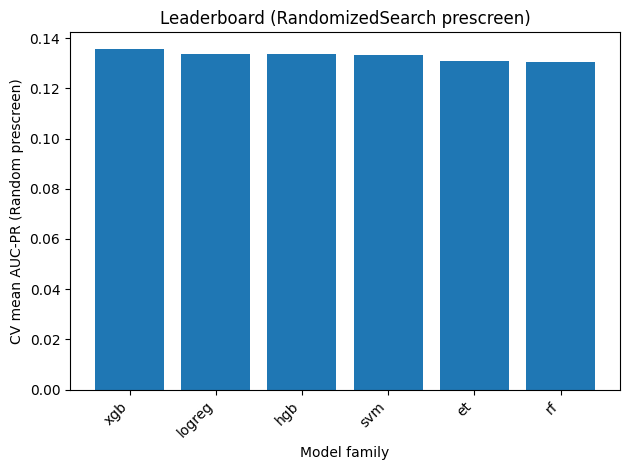

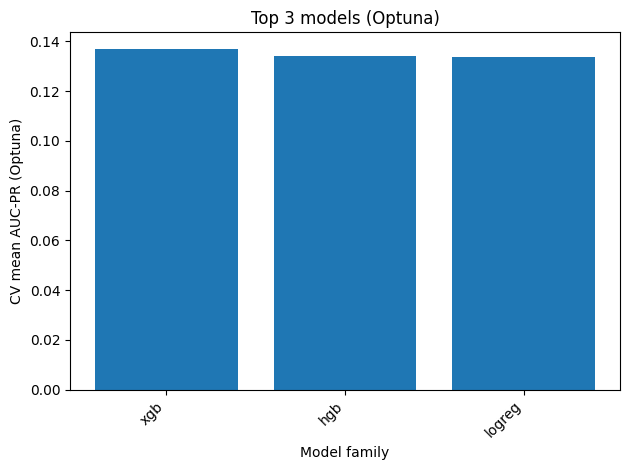

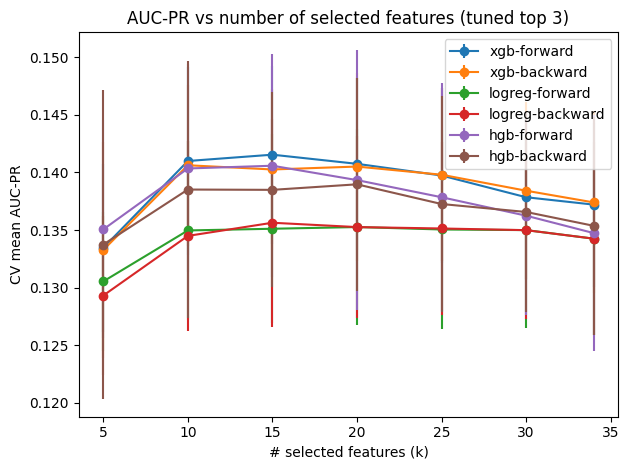

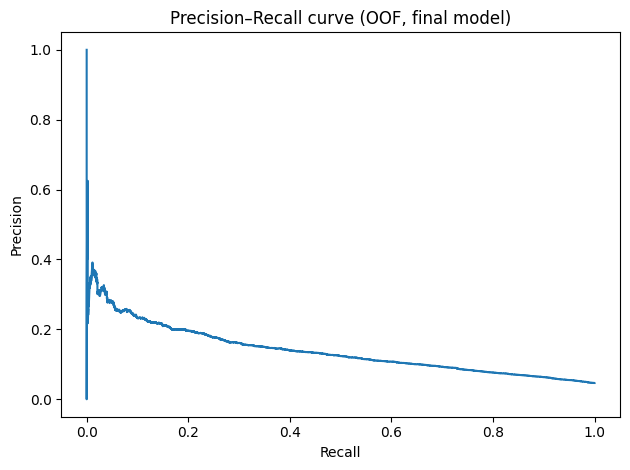

In [10]:
# =========================
# TRAIN-ONLY PIPELINE (No df_test usage)
# - Hyperparameter tuning + Feature selection: AUC-PR (average_precision) ✅
# - RandomizedSearch prescreen for all model families ✅
# - Optuna optimization for best 3 families ✅
# - Pick final (model + feature subset) by CV AUC-PR ✅
# - Threshold tuning on TRAIN OOF for labels: maximize Balanced Accuracy ✅
# - Fit final model on ALL training data ✅
# - Returns: final_estimator, final_cols, tuned_threshold, plus diagnostics/plots ✅
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    balanced_accuracy_score, confusion_matrix,
    roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

import xgboost as xgb
from scipy.stats import loguniform, randint, uniform

import optuna

RANDOM_STATE = 42

# -------------------------
# CONFIG
# -------------------------
CV_SPLITS = 5

# Stage 1: quick prescreen across all model families
N_ITER_RANDOM_SEARCH = 30

# Stage 2: Optuna for best 3 families
TOP_K_MODELS = 3
OPTUNA_TRIALS = 40

# Stage 3: Feature selection sizes (must be < n_features)
K_LIST = [5, 10, 15, 20, 25, 30, 34]

# Threshold tuning (OOF) objective for labels
THRESHOLD_MAX_CANDIDATES = 2000


# -------------------------
# Helpers
# -------------------------
def proba_or_score(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    return estimator.predict(X)


def cv_mean_aucpr(estimator, X, y, groups, n_splits=5):
    cv = GroupKFold(n_splits=n_splits)
    scores = []
    for tr_idx, va_idx in cv.split(X, y, groups):
        est = clone(estimator)
        est.fit(X.iloc[tr_idx], y[tr_idx])
        s = proba_or_score(est, X.iloc[va_idx])
        scores.append(average_precision_score(y[va_idx], s))
    return float(np.mean(scores))


def get_oof_scores(estimator, X, y, groups, n_splits=5):
    """Out-of-fold continuous scores using GroupKFold(userId)."""
    cv = GroupKFold(n_splits=n_splits)
    oof = np.empty(len(y), dtype=float)

    for tr_idx, va_idx in cv.split(X, y, groups):
        est = clone(estimator)
        est.fit(X.iloc[tr_idx], y[tr_idx])
        oof[va_idx] = proba_or_score(est, X.iloc[va_idx])

    return oof


def tune_threshold_for_balanced_accuracy(y_true, scores, max_thresholds=2000):
    """Pick threshold maximizing balanced accuracy."""
    thresholds = np.unique(scores)
    if len(thresholds) > max_thresholds:
        thresholds = np.quantile(scores, np.linspace(0.0, 1.0, max_thresholds))

    best_thr, best_bacc = 0.5, -1.0
    for thr in thresholds:
        y_pred = (scores >= thr).astype(int)
        bacc = balanced_accuracy_score(y_true, y_pred)
        if bacc > best_bacc:
            best_bacc = bacc
            best_thr = float(thr)
    return best_thr, float(best_bacc)


# -------------------------
# Models + spaces
# -------------------------
def build_estimator(model_type: str):
    mt = model_type.lower()

    if mt == "xgb":
        return xgb.XGBClassifier(
            eval_metric="aucpr",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            tree_method="hist",
        )

    if mt == "logreg":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                solver="lbfgs",
            ))
        ])

    if mt == "rf":
        return RandomForestClassifier(
            n_jobs=-1,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )

    if mt == "et":
        return ExtraTreesClassifier(
            n_jobs=-1,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )

    if mt == "hgb":
        return HistGradientBoostingClassifier(
            random_state=RANDOM_STATE,
        )

    if mt == "svm":
        base = LinearSVC(
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE
        )
        calibrated = CalibratedClassifierCV(estimator=base, method="sigmoid", cv=3)
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", calibrated),
        ])

    raise ValueError(f"Unknown model_type: {model_type}")


def param_distributions_random(model_type: str):
    """Broad RandomizedSearchCV spaces (prescreen)."""
    mt = model_type.lower()

    if mt == "xgb":
        return {
            "n_estimators": randint(200, 900),
            "learning_rate": loguniform(0.01, 0.2),
            "max_depth": randint(2, 9),
            "subsample": uniform(0.6, 0.4),
            "colsample_bytree": uniform(0.6, 0.4),
            "min_child_weight": randint(1, 20),
            "gamma": uniform(0.0, 6.0),
            "reg_alpha": loguniform(1e-8, 1e-1),
            "reg_lambda": loguniform(1e-2, 10.0),
            "scale_pos_weight": randint(1, 30),
        }

    if mt == "logreg":
        return {"model__C": loguniform(1e-3, 50.0)}

    if mt == "svm":
        return {"model__estimator__C": loguniform(1e-3, 50.0)}

    if mt == "rf":
        return {
            "n_estimators": randint(200, 900),
            "max_depth": [None, 5, 10, 20, 30],
            "min_samples_leaf": randint(1, 30),
            "max_features": ["sqrt", "log2", None],
        }

    if mt == "et":
        return {
            "n_estimators": randint(200, 1200),
            "max_depth": [None, 5, 10, 20, 30],
            "min_samples_leaf": randint(1, 20),
            "max_features": ["sqrt", "log2", None],
        }

    if mt == "hgb":
        return {
            "learning_rate": loguniform(0.01, 0.2),
            "max_leaf_nodes": randint(15, 120),
            "min_samples_leaf": randint(5, 80),
            "l2_regularization": loguniform(1e-6, 10.0),
            "max_iter": randint(100, 800),
        }

    raise ValueError(model_type)


def tune_random_search(model_type: str, X, y, groups, n_iter=30):
    est = build_estimator(model_type)
    dist = param_distributions_random(model_type)
    cv = GroupKFold(n_splits=CV_SPLITS)

    search = RandomizedSearchCV(
        estimator=est,
        param_distributions=dist,
        n_iter=n_iter,
        scoring="average_precision",
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1,
        refit=True
    )
    search.fit(X, y, groups=groups)
    return search


# -------------------------
# Optuna tuning for top 3
# -------------------------
def optuna_tune(model_type: str, X, y, groups, n_trials=40):
    mt = model_type.lower()

    def objective(trial: optuna.Trial):
        if mt == "xgb":
            params = dict(
                n_estimators=trial.suggest_int("n_estimators", 200, 1200),
                learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                max_depth=trial.suggest_int("max_depth", 2, 9),
                subsample=trial.suggest_float("subsample", 0.6, 1.0),
                colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
                min_child_weight=trial.suggest_int("min_child_weight", 1, 25),
                gamma=trial.suggest_float("gamma", 0.0, 6.0),
                reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 1e-1, log=True),
                reg_lambda=trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
                scale_pos_weight=trial.suggest_int("scale_pos_weight", 1, 30),
            )
            est = xgb.XGBClassifier(
                **params,
                eval_metric="aucpr",
                n_jobs=-1,
                random_state=RANDOM_STATE,
                tree_method="hist",
            )
            return cv_mean_aucpr(est, X, y, groups, n_splits=CV_SPLITS)

        if mt == "logreg":
            C = trial.suggest_float("C", 1e-3, 50.0, log=True)
            est = Pipeline([
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    C=C, max_iter=5000, class_weight="balanced", solver="lbfgs"
                ))
            ])
            return cv_mean_aucpr(est, X, y, groups, n_splits=CV_SPLITS)

        if mt == "svm":
            C = trial.suggest_float("C", 1e-3, 50.0, log=True)
            base = LinearSVC(C=C, class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE)
            calibrated = CalibratedClassifierCV(estimator=base, method="sigmoid", cv=3)
            est = Pipeline([("scaler", StandardScaler()), ("model", calibrated)])
            return cv_mean_aucpr(est, X, y, groups, n_splits=CV_SPLITS)

        if mt == "rf":
            params = dict(
                n_estimators=trial.suggest_int("n_estimators", 200, 1200),
                max_depth=trial.suggest_categorical("max_depth", [None, 5, 10, 20, 30]),
                min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 30),
                max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            )
            est = RandomForestClassifier(
                **params, n_jobs=-1, class_weight="balanced", random_state=RANDOM_STATE
            )
            return cv_mean_aucpr(est, X, y, groups, n_splits=CV_SPLITS)

        if mt == "et":
            params = dict(
                n_estimators=trial.suggest_int("n_estimators", 200, 1600),
                max_depth=trial.suggest_categorical("max_depth", [None, 5, 10, 20, 30]),
                min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
                max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            )
            est = ExtraTreesClassifier(
                **params, n_jobs=-1, class_weight="balanced", random_state=RANDOM_STATE
            )
            return cv_mean_aucpr(est, X, y, groups, n_splits=CV_SPLITS)

        if mt == "hgb":
            params = dict(
                learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                max_leaf_nodes=trial.suggest_int("max_leaf_nodes", 15, 140),
                min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 100),
                l2_regularization=trial.suggest_float("l2_regularization", 1e-6, 10.0, log=True),
                max_iter=trial.suggest_int("max_iter", 100, 1000),
            )
            est = HistGradientBoostingClassifier(**params, random_state=RANDOM_STATE)
            return cv_mean_aucpr(est, X, y, groups, n_splits=CV_SPLITS)

        raise ValueError(mt)

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_params = study.best_params

    # Build best estimator
    if mt == "xgb":
        best_est = xgb.XGBClassifier(
            **best_params,
            eval_metric="aucpr",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            tree_method="hist",
        )
    elif mt == "logreg":
        best_est = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                C=best_params["C"], max_iter=5000, class_weight="balanced", solver="lbfgs"
            ))
        ])
    elif mt == "svm":
        base = LinearSVC(
            C=best_params["C"], class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE
        )
        calibrated = CalibratedClassifierCV(estimator=base, method="sigmoid", cv=3)
        best_est = Pipeline([("scaler", StandardScaler()), ("model", calibrated)])
    elif mt == "rf":
        best_est = RandomForestClassifier(
            **best_params, n_jobs=-1, class_weight="balanced", random_state=RANDOM_STATE
        )
    elif mt == "et":
        best_est = ExtraTreesClassifier(
            **best_params, n_jobs=-1, class_weight="balanced", random_state=RANDOM_STATE
        )
    elif mt == "hgb":
        best_est = HistGradientBoostingClassifier(**best_params, random_state=RANDOM_STATE)
    else:
        raise ValueError(mt)

    return study, best_est


# -------------------------
# Feature selection (SFS)
# -------------------------
def sfs_curve_for_model(best_estimator, X, y, groups, k_list, direction, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    splits = list(gkf.split(X, y, groups))

    rows = []
    for k in k_list:
        if k >= X.shape[1]:
            continue

        selector = SequentialFeatureSelector(
            estimator=best_estimator,
            n_features_to_select=k,
            direction=direction,
            scoring="average_precision",
            cv=splits,
            n_jobs=-1
        )
        selector.fit(X, y)
        selected_cols = list(X.columns[selector.get_support()])

        fold_scores = []
        for tr_idx, va_idx in splits:
            est = clone(best_estimator)
            est.fit(X.iloc[tr_idx][selected_cols], y[tr_idx])
            s = proba_or_score(est, X.iloc[va_idx][selected_cols])
            fold_scores.append(average_precision_score(y[va_idx], s))

        rows.append({
            "k": k,
            "direction": direction,
            "mean_aucpr": float(np.mean(fold_scores)),
            "std_aucpr": float(np.std(fold_scores)),
            "selected_cols": selected_cols
        })

    return pd.DataFrame(rows)


# =========================
# RUN: TRAIN ONLY
# =========================

df_train = df_train_ready.copy()
if "anchor_date" in df_train.columns:
    df_train["anchor_date"] = pd.to_datetime(df_train["anchor_date"]).dt.floor("D")

DROP = {"userId", "anchor_date", "target_churn"}
feature_cols = [c for c in df_train.columns if c not in DROP]

X = df_train[feature_cols]
y = df_train["target_churn"].astype(int).values
groups = df_train["userId"].values

print("Train rows:", len(df_train), "| Features:", len(feature_cols))

# ---- Stage 1: RandomizedSearch prescreen
model_types = ["logreg", "xgb", "rf", "et", "hgb", "svm"]
random_search_results = {}

for mt in model_types:
    print("\n=== Random Search (prescreen):", mt, "===")
    rs = tune_random_search(mt, X, y, groups, n_iter=N_ITER_RANDOM_SEARCH)
    random_search_results[mt] = rs
    print("Best CV AUC-PR:", rs.best_score_)

ranking_rs = sorted(
    [(mt, float(random_search_results[mt].best_score_)) for mt in model_types],
    key=lambda x: x[1],
    reverse=True
)

print("\n=== Prescreen ranking (CV AUC-PR) ===")
for mt, score in ranking_rs:
    print(f"{mt:6s}  {score:.5f}")

top3_types = [mt for mt, _ in ranking_rs[:TOP_K_MODELS]]
print("\nTop 3 for Optuna:", top3_types)

# ---- Stage 2: Optuna tuning
optuna_results = {}
for mt in top3_types:
    print("\n=== Optuna tuning:", mt, "===")
    study, best_est = optuna_tune(mt, X, y, groups, n_trials=OPTUNA_TRIALS)
    optuna_results[mt] = {"study": study, "estimator": best_est, "best_score": float(study.best_value)}
    print("Optuna best CV AUC-PR:", study.best_value)

ranking_optuna = sorted(
    [(mt, optuna_results[mt]["best_score"]) for mt in top3_types],
    key=lambda x: x[1],
    reverse=True
)

print("\n=== Optuna ranking (CV AUC-PR) ===")
for mt, score in ranking_optuna:
    print(f"{mt:6s}  {score:.5f}")

# ---- Stage 3: Feature selection for tuned top3
fs_results = {}
for mt in top3_types:
    print("\n=== Feature selection for:", mt, "===")
    tuned_est = optuna_results[mt]["estimator"]

    df_fwd = sfs_curve_for_model(tuned_est, X, y, groups, K_LIST, "forward", n_splits=CV_SPLITS)
    df_bwd = sfs_curve_for_model(tuned_est, X, y, groups, K_LIST, "backward", n_splits=CV_SPLITS)
    fs_results[mt] = pd.concat([df_fwd, df_bwd], ignore_index=True)

    best_row = fs_results[mt].sort_values("mean_aucpr", ascending=False).iloc[0]
    print(f"Best FS for {mt}: dir={best_row['direction']} k={best_row['k']} aucpr={best_row['mean_aucpr']:.5f}")

# ---- Stage 4: Pick final (model + feature subset)
cand = []
for mt in top3_types:
    tmp = fs_results[mt].copy()
    tmp["model_type"] = mt
    cand.append(tmp)
cand = pd.concat(cand, ignore_index=True)

best_global = cand.sort_values("mean_aucpr", ascending=False).iloc[0]
final_model_type = best_global["model_type"]
final_cols = best_global["selected_cols"]
final_estimator = optuna_results[final_model_type]["estimator"]

print("\n=== FINAL CHOICE ===")
print("Model:", final_model_type)
print("FS direction:", best_global["direction"], "| k:", int(best_global["k"]))
print("CV AUC-PR:", float(best_global["mean_aucpr"]))
print("Features used:", len(final_cols))

# ---- Threshold tuning (OOF) for labels
oof_scores = get_oof_scores(final_estimator, X[final_cols], y, groups, n_splits=CV_SPLITS)
thr, oof_bacc = tune_threshold_for_balanced_accuracy(y, oof_scores, max_thresholds=THRESHOLD_MAX_CANDIDATES)

y_oof_pred = (oof_scores >= thr).astype(int)
cm_oof = confusion_matrix(y, y_oof_pred)

print("\n=== THRESHOLD (OOF tuned) ===")
print("thr maximizing OOF balanced-accuracy:", thr)
print("OOF balanced-accuracy:", round(oof_bacc, 5))
print("OOF confusion matrix:\n", cm_oof)

# Optional: report OOF ROC-AUC for diagnostics
try:
    oof_rocauc = roc_auc_score(y, oof_scores)
    print("OOF ROC-AUC:", round(oof_rocauc, 5))
except Exception:
    pass

# ---- Fit final model on ALL training data (for downstream test pipeline)
final_estimator.fit(X[final_cols], y)

print("\n=== READY FOR INFERENCE ===")
print("final_estimator: trained on ALL df_train_ready")
print("final_cols: list of selected features")
print("thr: tuned threshold for hard labels")

# =========================
# PLOTS (TRAIN OOF diagnostics)
# =========================

# Plot 1: Prescreen leaderboard
plt.figure()
plt.bar([x[0] for x in ranking_rs], [x[1] for x in ranking_rs])
plt.xlabel("Model family")
plt.ylabel("CV mean AUC-PR (Random prescreen)")
plt.title("Leaderboard (RandomizedSearch prescreen)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Plot 2: Optuna leaderboard (Top 3)
plt.figure()
plt.bar([x[0] for x in ranking_optuna], [x[1] for x in ranking_optuna])
plt.xlabel("Model family")
plt.ylabel("CV mean AUC-PR (Optuna)")
plt.title("Top 3 models (Optuna)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# Plot 3: AUC-PR vs #features for tuned top3
plt.figure()
for mt in top3_types:
    dfp = fs_results[mt]
    for direction in ["forward", "backward"]:
        d = dfp[dfp["direction"] == direction].sort_values("k")
        plt.errorbar(d["k"], d["mean_aucpr"], yerr=d["std_aucpr"], marker="o", label=f"{mt}-{direction}")
plt.xlabel("# selected features (k)")
plt.ylabel("CV mean AUC-PR")
plt.title("AUC-PR vs number of selected features (tuned top 3)")
plt.legend()
plt.tight_layout()

# Plot 4: PR curve (OOF, final)
prec, rec, _ = precision_recall_curve(y, oof_scores)
plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curve (OOF, final model)")
plt.tight_layout()

plt.show()


In [11]:
def generate_kaggle_submission(model, df_logs_full, feature_cols, all_test_user_ids, output_file='submission.csv', seuil=0.5):
    """
    Génère la soumission en format BINAIRE avec correction automatique des types d'IDs.
    """
    print("\n--- Génération du fichier de soumission ROBUSTE (Mode Binaire) ---")

    # 1. Date de référence
    last_date = df_logs_full['time'].max()
    print(f"Anchor Date : {last_date}")

    # 2. Calcul des features
    X_test_active = compute_features_at_anchor(df_logs_full, last_date)

    if X_test_active is None:
        X_test_active = pd.DataFrame()
        print("Attention : Aucun utilisateur actif sur la dernière fenêtre !")

    # 3. Prédiction
    if not X_test_active.empty:
        for col in feature_cols:
            if col not in X_test_active.columns:
                X_test_active[col] = 0
        X_test_active = X_test_active[feature_cols]

        active_probs = model.predict_proba(X_test_active)[:, 1]

        df_preds = pd.DataFrame({
            'userId': X_test_active.index,
            'prediction': active_probs
        })
    else:
        df_preds = pd.DataFrame(columns=['userId', 'prediction'])

    # 4. Fusion avec la liste complète
    final_submission = pd.DataFrame({'userId': all_test_user_ids})

    # --- CORRECTION ICI : HARMONISATION DES TYPES ---
    # On convertit les deux colonnes en String pour être sûr qu'elles matchent
    final_submission['userId'] = final_submission['userId'].astype(str)
    df_preds['userId'] = df_preds['userId'].astype(str)

    # On retire les doublons éventuels pour éviter d'exploser le nombre de lignes
    final_submission = final_submission.drop_duplicates(subset=['userId'])
    df_preds = df_preds.drop_duplicates(subset=['userId'])

    # Maintenant le merge va fonctionner
    final_submission = final_submission.merge(df_preds, on='userId', how='left')

    # 5. Gestion des manquants
    avg_proba = final_submission['prediction'].mean()
    if pd.isna(avg_proba): avg_proba = 0.5

    missing_count = final_submission['prediction'].isna().sum()
    print(f"Utilisateurs inactifs : {missing_count} (Remplis avec la proba moyenne : {avg_proba:.4f})")

    final_submission['prediction'] = final_submission['prediction'].fillna(avg_proba)

    # 6. Application du Seuil
    final_submission['is_churn'] = (final_submission['prediction'] >= seuil).astype(int)

    # 7. Sauvegarde
    output_df = final_submission[['userId', 'is_churn']]
    output_df.columns = ['id', 'target']

    # On s'assure que le fichier final n'a pas d'index inutile
    output_df.to_csv(output_file, index=False)
    print(f"Sauvegardé : {output_file} ({len(output_df)} lignes)")

    return output_df

In [19]:
sample = pd.read_csv('../../data/churn-prediction-25-26/example_submission.csv')
all_users_list = sample['id'].unique()
all_users_list

#kaggle_challenge/data/churn-prediction-25-26/example_submission.csv

test_set=load_and_clean_data("../../data/churn-prediction-25-26/test.parquet")

submit_df = generate_kaggle_submission(final_estimator, test_set, final_cols, all_users_list, seuil=thr)

Chargement et Feature Engineering 'Statique'...
Données prêtes : 4393179 lignes.

--- Génération du fichier de soumission ROBUSTE (Mode Binaire) ---
Anchor Date : 2018-11-20 00:00:00
Utilisateurs inactifs : 63 (Remplis avec la proba moyenne : 0.2659)
Sauvegardé : submission.csv (2904 lignes)


In [27]:
#pd.DataFrame(data=fs_results).to_csv("feature_cols.csv")
pd.DataFrame(data = fs_results["xgb"]).to_csv("feature_cols_xgb.csv")
pd.DataFrame(data = fs_results["logreg"]).to_csv("feature_cols_logreg.csv")
pd.DataFrame(data = fs_results["hgb"]).to_csv("feature_cols_hgb.csv")

=== Optuna ranking (CV AUC-PR) ===
xgb     0.13679
hgb     0.13422
logreg  0.13387




=== Feature selection for: xgb ===
Best FS for xgb: dir=forward k=15 aucpr=0.14153

=== Feature selection for: logreg ===
Best FS for logreg: dir=backward k=15 aucpr=0.13563

=== Feature selection for: hgb ===
Best FS for hgb: dir=forward k=15 aucpr=0.14058

=== FINAL CHOICE ===
Model: xgb
FS direction: forward | k: 15
CV AUC-PR: 0.14153345141324802
Features used: 15

=== THRESHOLD (OOF tuned) ===
thr maximizing OOF balanced-accuracy: 0.2201831980145771
OOF balanced-accuracy: 0.68475
OOF confusion matrix:
 [[33045 15371]
 [  740  1624]]
OOF ROC-AUC: 0.74093




=== Prescreen ranking (CV AUC-PR) ===
xgb     0.13554
logreg  0.13383
hgb     0.13364
svm     0.13348
et      0.13072
rf      0.13047

In [ ]:
{'xgb':      k direction  mean_aucpr  std_aucpr  \
 0    5   forward    0.133458   0.007291
 1   10   forward    0.140985   0.008143
 2   15   forward    0.141533   0.007715
 3   20   forward    0.140741   0.007473
 4   25   forward    0.139728   0.007609
 5   30   forward    0.137843   0.007205
 6   34   forward    0.137202   0.007116
 7    5  backward    0.133271   0.009385
 8   10  backward    0.140616   0.006993
 9   15  backward    0.140251   0.007022
 10  20  backward    0.140504   0.008151
 11  25  backward    0.139795   0.007494
 12  30  backward    0.138409   0.007680
 13  34  backward    0.137392   0.007895

                                         selected_cols
 0   [history_Roll Advert, history_Thumbs Down, his...
 1   [recent_Upgrade, history_page, history_session...
 2   [recent_Upgrade, history_page, history_length,...
 3   [recent_Error, recent_Submit Downgrade, recent...
 4   [gap_acceleration, recent_page, recent_song, r...
 5   [avg_gap_days, gap_acceleration, recent_page, ...
 6   [avg_gap_days, last_gap_days, avg_song_duratio...
 7   [history_sessionId, history_Roll Advert, histo...
 8   [recent_Upgrade, history_song, history_session...
 9   [gap_acceleration, recent_page, recent_Thumbs ...
 10  [gap_acceleration, recent_page, recent_song, r...
 11  [gap_acceleration, recent_page, recent_song, r...
 12  [avg_gap_days, last_gap_days, gap_acceleration...
 13  [avg_gap_days, last_gap_days, avg_song_duratio...  ,
 'logreg':      k direction  mean_aucpr  std_aucpr  \
 0    5   forward    0.130543   0.006054
 1   10   forward    0.134962   0.007750
 2   15   forward    0.135110   0.008201
 3   20   forward    0.135257   0.008520
 4   25   forward    0.135046   0.008666
 5   30   forward    0.134992   0.008533
 6   34   forward    0.134250   0.008377
 7    5  backward    0.129319   0.006868
 8   10  backward    0.134491   0.008213
 9   15  backward    0.135630   0.009016
 10  20  backward    0.135254   0.007873
 11  25  backward    0.135133   0.007540
 12  30  backward    0.134988   0.007682
 13  34  backward    0.134250   0.008377

                                         selected_cols
 0   [history_Roll Advert, history_Thumbs Down, his...
 1   [gap_acceleration, recent_sessionId, history_p...
 2   [avg_song_duration, std_song_duration, gap_acc...
 3   [avg_gap_days, avg_song_duration, std_song_dur...
 4   [avg_gap_days, avg_song_duration, std_song_dur...
 5   [avg_gap_days, last_gap_days, avg_song_duratio...
 6   [avg_gap_days, last_gap_days, avg_song_duratio...
 7   [recent_page, history_Roll Advert, history_Thu...
 8   [recent_page, recent_sessionId, recent_Thumbs ...
 9   [std_song_duration, gap_acceleration, recent_p...
 10  [last_gap_days, std_song_duration, gap_acceler...
 11  [avg_gap_days, last_gap_days, avg_song_duratio...
 12  [avg_gap_days, last_gap_days, avg_song_duratio...
 13  [avg_gap_days, last_gap_days, avg_song_duratio...  ,
 'hgb':      k direction  mean_aucpr  std_aucpr  \
 0    5   forward    0.135052   0.009449
 1   10   forward    0.140338   0.009022
 2   15   forward    0.140576   0.009690
 3   20   forward    0.139329   0.011300
 4   25   forward    0.137845   0.009871
 5   30   forward    0.136243   0.008621
 6   34   forward    0.134734   0.010230
 7    5  backward    0.133740   0.013417
 8   10  backward    0.138510   0.011179
 9   15  backward    0.138484   0.008444
 10  20  backward    0.138963   0.009262
 11  25  backward    0.137255   0.009373
 12  30  backward    0.136564   0.008637
 13  34  backward    0.135364   0.009456

                                         selected_cols
 0   [history_sessionId, history_Roll Advert, histo...
 1   [recent_Error, recent_Add Friend, history_page...
 2   [recent_Thumbs Up, recent_Error, recent_Add Fr...
 3   [last_gap_days, std_song_duration, recent_Thum...
 4   [last_gap_days, avg_song_duration, std_song_du...
 5   [last_gap_days, avg_song_duration, std_song_du...
 6   [avg_gap_days, last_gap_days, avg_song_duratio...
 7   [history_Roll Advert, history_Thumbs Down, his...
 8   [avg_gap_days, history_page, history_Roll Adve...
 9   [avg_gap_days, recent_song, recent_length, his...
 10  [avg_gap_days, avg_song_duration, std_song_dur...
 11  [avg_gap_days, last_gap_days, avg_song_duratio...
 12  [avg_gap_days, last_gap_days, avg_song_duratio...
 13  [avg_gap_days, last_gap_days, avg_song_duratio...  }

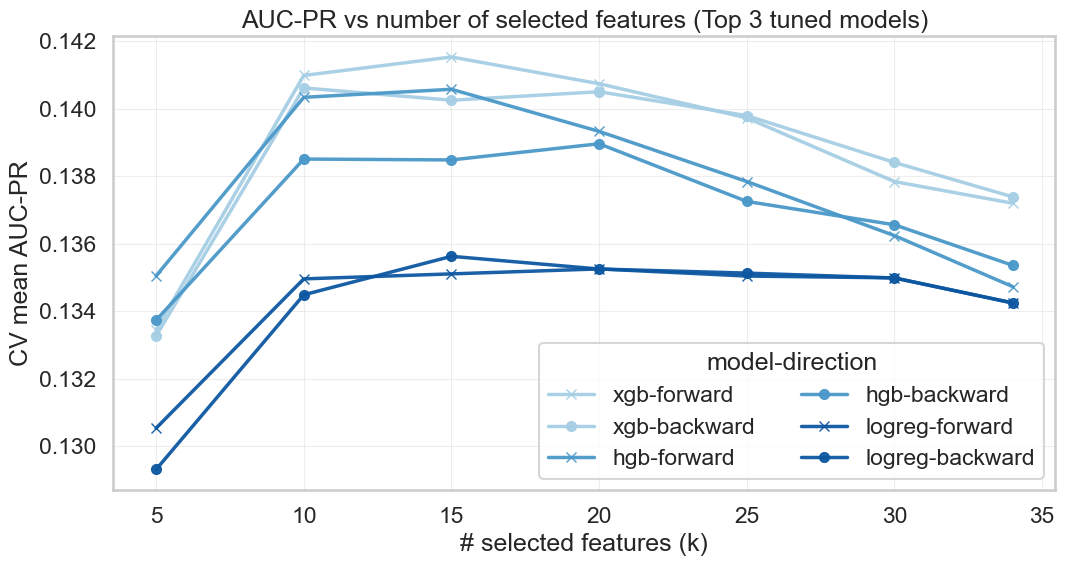

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Data (from your dict, reduced to plotting columns) ---
fs_results = {
    "xgb": pd.DataFrame({
        "k":[5,10,15,20,25,30,34,5,10,15,20,25,30,34],
        "direction":["forward"]*7+["backward"]*7,
        "mean_aucpr":[0.133458,0.140985,0.141533,0.140741,0.139728,0.137843,0.137202,
                     0.133271,0.140616,0.140251,0.140504,0.139795,0.138409,0.137392],
    }),
    "logreg": pd.DataFrame({
        "k":[5,10,15,20,25,30,34,5,10,15,20,25,30,34],
        "direction":["forward"]*7+["backward"]*7,
        "mean_aucpr":[0.130543,0.134962,0.135110,0.135257,0.135046,0.134992,0.134250,
                     0.129319,0.134491,0.135630,0.135254,0.135133,0.134988,0.134250],
    }),
    "hgb": pd.DataFrame({
        "k":[5,10,15,20,25,30,34,5,10,15,20,25,30,34],
        "direction":["forward"]*7+["backward"]*7,
        "mean_aucpr":[0.135052,0.140338,0.140576,0.139329,0.137845,0.136243,0.134734,
                     0.133740,0.138510,0.138484,0.138963,0.137255,0.136564,0.135364],
    }),
}

# 3 shades of blue: one per model
cmap = plt.cm.Blues
model_colors = {
    "xgb": cmap(0.35),
    "hgb": cmap(0.60),
    "logreg": cmap(0.85),
}

# Markers: forward = x, backward = o
marker_by_dir = {"forward": "x", "backward": "o"}

plt.figure(figsize=(11, 6))
ax = plt.gca()

for model in ["xgb", "hgb", "logreg"]:
    for direction in ["forward", "backward"]:
        d = fs_results[model]
        d = d[d["direction"] == direction].sort_values("k")
        ax.plot(
            d["k"].values,
            d["mean_aucpr"].values,
            marker=marker_by_dir[direction],
            linewidth=2.5,
            markersize=7,
            label=f"{model}-{direction}",
            color=model_colors[model],
            alpha=0.95
        )

ax.set_title("AUC-PR vs number of selected features (Top 3 tuned models)")
ax.set_xlabel("# selected features (k)")
ax.set_ylabel("CV mean AUC-PR")
ax.grid(True, which="major", linewidth=0.8, alpha=0.35)

ax.legend(title="model-direction", ncol=2, frameon=True, loc="best")
plt.tight_layout()
plt.show()


In [31]:
import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    balanced_accuracy_score,
    confusion_matrix,
)

# ---- helpers (same idea as your pipeline) ----
def get_oof_scores_for_estimator(estimator, X, y, groups, n_splits=5):
    """
    Return out-of-fold scores for any estimator.
    Uses predict_proba if available, else decision_function.
    """
    cv = GroupKFold(n_splits=n_splits)
    oof = np.empty(len(y), dtype=float)

    for tr_idx, va_idx in cv.split(X, y, groups):
        est = estimator.__class__(**estimator.get_params())
        est.fit(X.iloc[tr_idx], y[tr_idx])

        if hasattr(est, "predict_proba"):
            s = est.predict_proba(X.iloc[va_idx])[:, 1]
        elif hasattr(est, "decision_function"):
            s = est.decision_function(X.iloc[va_idx])
        else:
            # fallback: hard labels (not ideal but works)
            s = est.predict(X.iloc[va_idx]).astype(float)

        oof[va_idx] = s

    return oof


def tune_threshold_for_balanced_accuracy(y_true, scores, max_thresholds=2000):
    thresholds = np.unique(scores)
    if len(thresholds) > max_thresholds:
        thresholds = np.quantile(scores, np.linspace(0.0, 1.0, max_thresholds))

    best_thr, best_bacc = 0.5, -1.0
    for thr in thresholds:
        y_pred = (scores >= thr).astype(int)
        bacc = balanced_accuracy_score(y_true, y_pred)
        if bacc > best_bacc:
            best_bacc = bacc
            best_thr = float(thr)

    return best_thr, float(best_bacc)


def precision_recall_at_threshold(y_true, scores, thr):
    y_pred = (scores >= thr).astype(int)
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    prec = tp / (tp + fp + 1e-12)
    rec = tp / (tp + fn + 1e-12)
    return float(prec), float(rec)


# =========================
# Dummy baseline evaluation
# =========================
# Use the SAME feature set and groups you used for your final evaluation.
# Recommended:
# - X_base = X[final_cols]  (to compare apples-to-apples with the final model)
# Or:
# - X_base = X[feature_cols] (baseline on full features)

X_base = X[final_cols]          # <-- change if needed
y_base = y
g_base = groups

dummy_strategies = [
    ("most_frequent", DummyClassifier(strategy="most_frequent", random_state=42)),
    ("prior", DummyClassifier(strategy="prior", random_state=42)),
]

rows = []
for name, dummy in dummy_strategies:
    oof_scores = get_oof_scores_for_estimator(dummy, X_base, y_base, g_base, n_splits=CV_SPLITS)

    aucpr = average_precision_score(y_base, oof_scores)
    # roc_auc can fail if scores are constant; handle safely
    try:
        rocauc = roc_auc_score(y_base, oof_scores)
    except Exception:
        rocauc = np.nan

    thr, oof_bacc = tune_threshold_for_balanced_accuracy(y_base, oof_scores)
    y_pred = (oof_scores >= thr).astype(int)
    cm = confusion_matrix(y_base, y_pred)
    prec, rec = precision_recall_at_threshold(y_base, oof_scores, thr)

    rows.append({
        "model": f"Dummy({name})",
        "OOF_AUC_PR": aucpr,
        "OOF_ROC_AUC": rocauc,
        "OOF_thr_bal_acc": thr,
        "OOF_balanced_accuracy": oof_bacc,
        "OOF_precision@thr": prec,
        "OOF_recall@thr": rec,
        "OOF_confusion_matrix": cm,
    })

baseline_report = pd.DataFrame(rows)
baseline_report


,model,OOF_AUC_PR,OOF_ROC_AUC,OOF_thr_bal_acc,OOF_balanced_accuracy,OOF_precision@thr,OOF_recall@thr,OOF_confusion_matrix
0,Dummy(most_frequent),0.046554,0.500000,0.000000,0.5,0.046554,1.0,"[[0, 48416], [0, 2364]]"
1,Dummy(prior),0.044922,0.486158,0.046007,0.5,0.046554,1.0,"[[0, 48416], [0, 2364]]"


In [32]:
baseline_report

,model,OOF_AUC_PR,OOF_ROC_AUC,OOF_thr_bal_acc,OOF_balanced_accuracy,OOF_precision@thr,OOF_recall@thr,OOF_confusion_matrix
0,Dummy(most_frequent),0.046554,0.500000,0.000000,0.5,0.046554,1.0,"[[0, 48416], [0, 2364]]"
1,Dummy(prior),0.044922,0.486158,0.046007,0.5,0.046554,1.0,"[[0, 48416], [0, 2364]]"


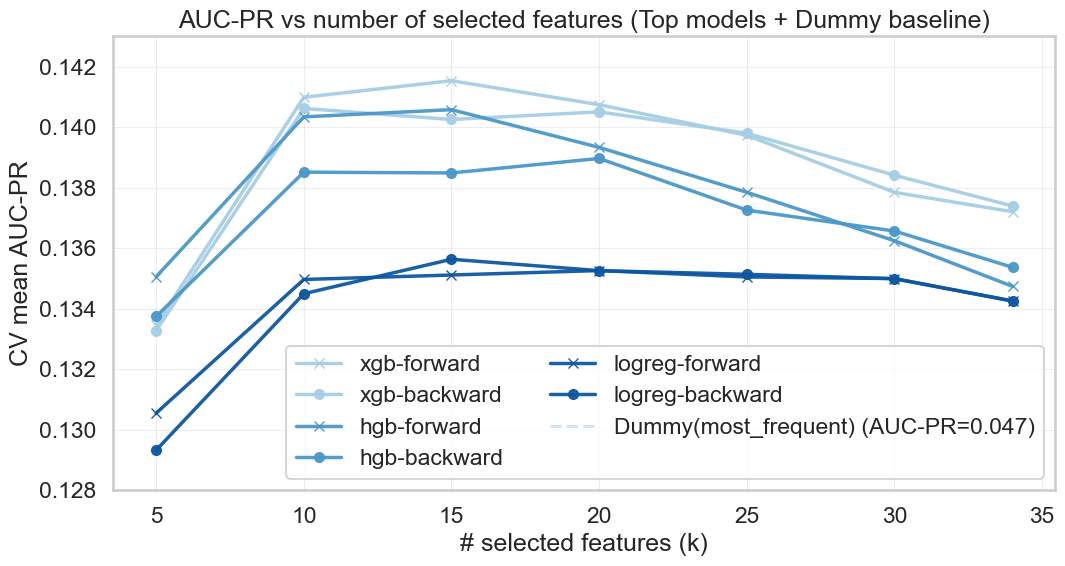

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Your FS results (same as before) ---
fs_results = {
    "xgb": pd.DataFrame({
        "k":[5,10,15,20,25,30,34,5,10,15,20,25,30,34],
        "direction":["forward"]*7+["backward"]*7,
        "mean_aucpr":[0.133458,0.140985,0.141533,0.140741,0.139728,0.137843,0.137202,
                     0.133271,0.140616,0.140251,0.140504,0.139795,0.138409,0.137392],
    }),
    "logreg": pd.DataFrame({
        "k":[5,10,15,20,25,30,34,5,10,15,20,25,30,34],
        "direction":["forward"]*7+["backward"]*7,
        "mean_aucpr":[0.130543,0.134962,0.135110,0.135257,0.135046,0.134992,0.134250,
                     0.129319,0.134491,0.135630,0.135254,0.135133,0.134988,0.134250],
    }),
    "hgb": pd.DataFrame({
        "k":[5,10,15,20,25,30,34,5,10,15,20,25,30,34],
        "direction":["forward"]*7+["backward"]*7,
        "mean_aucpr":[0.135052,0.140338,0.140576,0.139329,0.137845,0.136243,0.134734,
                     0.133740,0.138510,0.138484,0.138963,0.137255,0.136564,0.135364],
    }),
}

# --- Dummy baseline (from your baseline report) ---
DUMMY_NAME = "Dummy(most_frequent)"
DUMMY_AUCPR = 0.046554  # OOF_AUC_PR from your table

# 3 shades of blue: one per model
cmap = plt.cm.Blues
model_colors = {
    "xgb": cmap(0.35),
    "hgb": cmap(0.60),
    "logreg": cmap(0.85),
}

# Markers: forward = x, backward = o
marker_by_dir = {"forward": "x", "backward": "o"}

plt.figure(figsize=(11, 6))
ax = plt.gca()

# Plot model curves
for model in ["xgb", "hgb", "logreg"]:
    for direction in ["forward", "backward"]:
        d = fs_results[model]
        d = d[d["direction"] == direction].sort_values("k")
        ax.plot(
            d["k"].values,
            d["mean_aucpr"].values,
            marker=marker_by_dir[direction],
            linewidth=2.5,
            markersize=7,
            label=f"{model}-{direction}",
            color=model_colors[model],
            alpha=0.95
        )

# Add Dummy baseline as horizontal line
ax.axhline(
    y=DUMMY_AUCPR,
    linestyle="--",
    linewidth=2.2,
    color=cmap(0.20),   # light blue
    alpha=0.9,
    label=f"{DUMMY_NAME} (AUC-PR={DUMMY_AUCPR:.3f})"
)

ax.set_ylim(0.128, 0.143)

ax.set_title("AUC-PR vs number of selected features (Top models + Dummy baseline)")
ax.set_xlabel("# selected features (k)")
ax.set_ylabel("CV mean AUC-PR")
ax.grid(True, which="major", linewidth=0.8, alpha=0.35)
ax.legend(title="", ncol=2, frameon=True, loc="best")

plt.tight_layout()
plt.show()


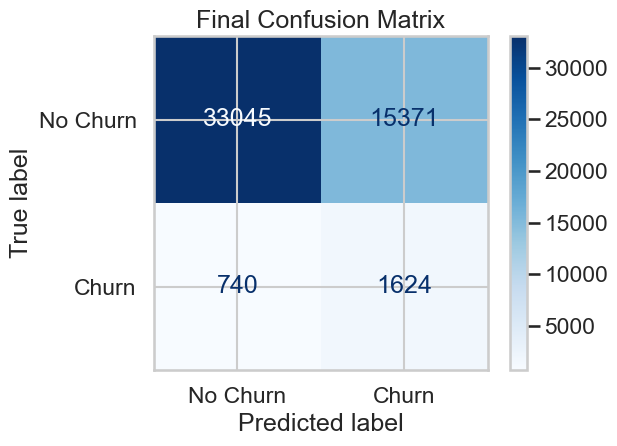

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = np.array([[33045, 15371],
               [  740,  1624]])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(values_format="d", cmap="Blues")
plt.title("Final Confusion Matrix")
plt.tight_layout()
plt.show()


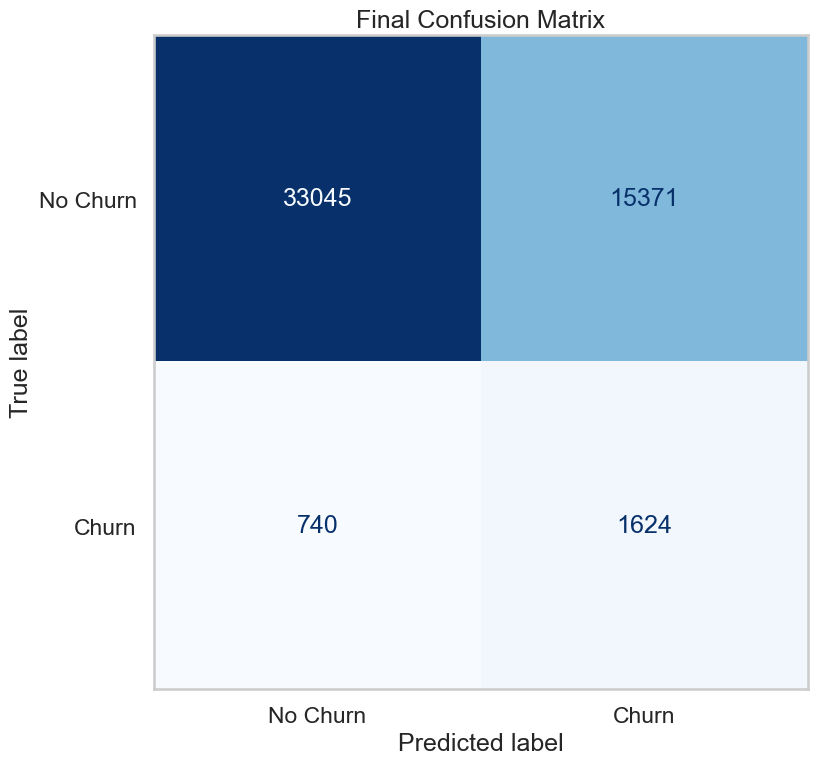

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = np.array([[33045, 15371],
               [  740,  1624]])

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No Churn", "Churn"])

fig, ax = plt.subplots(figsize=(10,8))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)  # <- no legend/colorbar

# remove “cell lines” look
ax.images[0].set_interpolation("none")   # or "nearest"
ax.grid(False)

ax.set_title("Final Confusion Matrix")
plt.tight_layout()
plt.show()


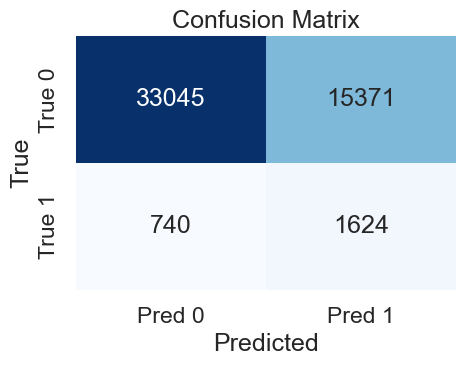

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm = np.array([[33045, 15371],
               [  740,  1624]])

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()
